# 04 — Deep Learning Experiments (MLP) — Home Credit Default Risk

**Scope**: the complete Deep Learning track. An MLP for tabular binary classification, trained on the
same features, the same Train/Test split and the same business cost matrix as the classical track,
then compared head-to-head against the saved classical champion (calibrated Logistic Regression).

**Inputs** (loaded, never recomputed): `X_train`, `X_test`, `y_train`, `y_test`, the fitted
`preprocessing_pipeline.joblib`, the final feature list, and `best_classical_model.joblib`.

## The three rules that shape every design choice below

1. **The Test set is touched exactly once**, in Section 12, for a single final evaluation.
   Architecture choice, calibration and threshold are all decided on Train-derived splits only.
2. **The preprocessing is re-fitted, not reused as-is.** The saved `preprocessing_pipeline.joblib`
   was fitted on the *whole* Train set. If we used it to transform a validation split carved out of
   Train, that validation split would have contributed its own median/scale/categories to the
   transformer it is being evaluated with. We therefore `clone()` the preprocessor and fit the clone
   on the sub-train portion only. Same recipe, honest fit.
3. **The model that gets calibrated is the model that gets shipped.** See the note in Section 2 on
   why we do not retrain on the full Train set after calibration.

## Train-side split design

```
X_train (246,008 rows, 8.07% default)
        |
        +-- SUB-TRAIN  70%  -> fits the preprocessor, trains the MLP
        +-- VAL        15%  -> EarlyStopping, ReduceLROnPlateau, architecture selection
        +-- CAL        15%  -> probability calibration + business-cost threshold
```

Why a third split rather than the two the original plan called for: `VAL` drives early stopping and
the choice between MLP configurations, so the model is already mildly optimistic on it. Fitting the
calibrator and picking the decision threshold on that same split would inherit that optimism and
produce a threshold that looks better in the notebook than it is in production. `CAL` is untouched by
training and by model selection, so it is a clean surface for both.

**On the "retrain on full Train" step in the original plan**: retraining after calibration changes
the probability distribution the calibrator and threshold were fitted to, which silently invalidates
both. Since the MLP already trains on ~172k rows, the marginal gain from the extra 30% of rows is
small relative to that risk, so the selected `SUB-TRAIN` model *is* the final model. This is stated
explicitly in the saved metadata.

## 0. Imports & configuration

In [33]:
import os
import json
import joblib
import random
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, recall_score, precision_score,
    f1_score, confusion_matrix, brier_score_loss,
)
from sklearn.calibration import calibration_curve

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
sns.set_style("whitegrid")

keras.utils.set_random_seed(42)

# Business cost matrix - identical to the classical track, so the two are comparable
FN_COST = 10   # cost of missing an actual default
FP_COST = 1    # cost of wrongly rejecting a good applicant

PROJECT_ROOT = r"C:\Users\Kirolos George\OneDrive - Alexandria University\Desktop\projects\tech_trek_internship\credit risk project structure Project\project-name"
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "processed")
REPORTS_DIR   = os.path.join(PROJECT_ROOT, "reports")
FIGURES_DIR   = os.path.join(REPORTS_DIR, "figures")
MODELS_DIR    = os.path.join(PROJECT_ROOT, "models", "versioned_artifacts")

for d in (REPORTS_DIR, FIGURES_DIR, MODELS_DIR):
    os.makedirs(d, exist_ok=True)

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU") or "none (CPU training)")

TensorFlow: 2.21.0
GPU devices: none (CPU training)


In [34]:
import os

print("PROJECT_ROOT exists:", os.path.exists(PROJECT_ROOT))
print("X_train exists:", os.path.exists(os.path.join(PROCESSED_DIR, "X_train.csv")))

PROJECT_ROOT exists: True
X_train exists: True


## 1. Load saved artifacts

Everything comes from the EDA/feature-preparation and classical-ML notebooks. Nothing is recomputed.

In [35]:
X_train = pd.read_csv(os.path.join(PROCESSED_DIR, "X_train.csv"))
X_test  = pd.read_csv(os.path.join(PROCESSED_DIR, "X_test.csv"))
y_train = pd.read_csv(os.path.join(PROCESSED_DIR, "y_train.csv")).squeeze().astype(int)
y_test  = pd.read_csv(os.path.join(PROCESSED_DIR, "y_test.csv")).squeeze().astype(int)

preprocessor = joblib.load(os.path.join(MODELS_DIR, "preprocessing_pipeline.joblib"))

with open(os.path.join(REPORTS_DIR, "final_ml_feature_list.json")) as f:
    feature_lists = json.load(f)

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_test: ", X_test.shape, "| y_test: ", y_test.shape, "(shape only - untouched until Section 12)")
print("Train default rate:", round(float(y_train.mean()), 4))
print("Numeric features:", len(feature_lists["numeric_features"]),
      "| Categorical features:", len(feature_lists["categorical_features"]))

assert list(X_train.columns) == list(X_test.columns), "X_train/X_test column mismatch!"
assert len(X_train) == len(y_train) and len(X_test) == len(y_test)
print("\n[OK] Artifacts loaded, schemas aligned.")

X_train: (246008, 586) | y_train: (246008,)
X_test:  (61503, 586) | y_test:  (61503,) (shape only - untouched until Section 12)
Train default rate: 0.0807
Numeric features: 570 | Categorical features: 16

[OK] Artifacts loaded, schemas aligned.


In [37]:
# Load the classical champion saved by the ML notebook.
champion_bundle = joblib.load(
    os.path.join(
        MODELS_DIR,
        "best_classical_model.joblib"
    )
)

if isinstance(champion_bundle, dict):

    champion_pipeline = champion_bundle.get(
        "pipeline",
        champion_bundle.get("model")
    )

    champion_calibrator = champion_bundle.get(
        "calibrator"
    )

    champion_calib_method = champion_bundle.get(
        "calibration_method"
    )

    # Correct key used when the artifact was saved
    champion_threshold = champion_bundle.get(
        "decision_threshold",
        champion_bundle.get("threshold")
    )

    champion_name = champion_bundle.get(
        "model_name",
        "LogisticRegression"
    )

else:
    champion_pipeline = champion_bundle
    champion_calibrator = None
    champion_calib_method = None
    champion_threshold = None
    champion_name = "LogisticRegression"


print("Classical champion:", champion_name)
print("Calibration method:", champion_calib_method)
print("Decision threshold:", champion_threshold)
print("Calibrator loaded:", champion_calibrator is not None)

Classical champion: LogisticRegression
Calibration method: isotonic
Decision threshold: 0.09
Calibrator loaded: True


## 2. Prepare the MLP data

Three stratified splits carved out of Train (70 / 15 / 15), made in two steps so the stratification
holds in all three. The preprocessor clone is then fitted on `SUB-TRAIN` only and used to transform
the other two.

**Memory note**: the transformed matrix is 716 dense columns. In float64 that is roughly 1.4 GB for
Train alone; every transformed array is therefore cast to `float32` immediately, which halves it with
no practical loss for a neural network.

In [38]:
# Step 1: hold out 30% of Train, stratified
X_sub, X_holdout, y_sub, y_holdout = train_test_split(
    X_train, y_train,
    test_size=0.30,
    stratify=y_train,
    random_state=RANDOM_STATE,
)

# Step 2: split that 30% evenly into VAL and CAL (15% / 15% of Train), stratified again
X_val, X_cal, y_val, y_cal = train_test_split(
    X_holdout, y_holdout,
    test_size=0.50,
    stratify=y_holdout,
    random_state=RANDOM_STATE,
)

for name, X_part, y_part in [("SUB-TRAIN", X_sub, y_sub), ("VAL", X_val, y_val), ("CAL", X_cal, y_cal)]:
    print(f"{name:<10} rows={len(X_part):>7,} ({len(X_part)/len(X_train):.1%} of Train) "
          f"default rate={y_part.mean():.4f}")

assert len(X_sub) + len(X_val) + len(X_cal) == len(X_train), "Splits do not reconstruct Train!"
assert X_sub.index.intersection(X_val.index).empty
assert X_sub.index.intersection(X_cal.index).empty
assert X_val.index.intersection(X_cal.index).empty
print("\n[OK] Three disjoint stratified splits, default rate preserved in each.")

SUB-TRAIN  rows=172,205 (70.0% of Train) default rate=0.0807
VAL        rows= 36,901 (15.0% of Train) default rate=0.0807
CAL        rows= 36,902 (15.0% of Train) default rate=0.0807

[OK] Three disjoint stratified splits, default rate preserved in each.


In [39]:
# Fit a CLONE of the saved preprocessor on SUB-TRAIN only (rule 2 in the header).
mlp_preprocessor = clone(preprocessor)
mlp_preprocessor.fit(X_sub)

X_sub_t = mlp_preprocessor.transform(X_sub).astype("float32")
X_val_t = mlp_preprocessor.transform(X_val).astype("float32")
X_cal_t = mlp_preprocessor.transform(X_cal).astype("float32")

y_sub_a = y_sub.to_numpy().astype("float32")
y_val_a = y_val.to_numpy().astype("float32")
y_cal_a = y_cal.to_numpy().astype("float32")

INPUT_DIM = X_sub_t.shape[1]

print("X_sub_t:", X_sub_t.shape, X_sub_t.dtype, f"({X_sub_t.nbytes / 1e9:.2f} GB)")
print("X_val_t:", X_val_t.shape)
print("X_cal_t:", X_cal_t.shape)
print("Input dimension for the MLP:", INPUT_DIM)

assert X_val_t.shape[1] == X_cal_t.shape[1] == INPUT_DIM, "Transformed width mismatch across splits!"
assert np.isfinite(X_sub_t).all(), "Non-finite values after preprocessing - investigate before training."
print("\n[OK] Preprocessing fitted on SUB-TRAIN only; VAL and CAL transformed with it.")

X_sub_t: (172205, 716) float32 (0.49 GB)
X_val_t: (36901, 716)
X_cal_t: (36902, 716)
Input dimension for the MLP: 716

[OK] Preprocessing fitted on SUB-TRAIN only; VAL and CAL transformed with it.


## 3. Class imbalance strategy — `class_weight` only

Same decision as the classical track: weight the loss rather than resample. SMOTE would have to be
applied inside the training split only, and with 716 dense columns and ~172k rows it is expensive for
a benefit the classical track already showed to be marginal (SMOTE never beat `class_weight` on
PR-AUC there). Weights are computed on `SUB-TRAIN`, not on the full Train set, so they match exactly
what the network sees.

In [41]:
class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=y_sub,
)
class_weight_dict = {0: float(class_weights_arr[0]), 1: float(class_weights_arr[1])}

print("class_weight='balanced' on SUB-TRAIN:", {k: round(v, 4) for k, v in class_weight_dict.items()})
print(f"Positive class prevalence: {y_sub.mean():.4f} "
      f"(imbalance ratio {(y_sub == 0).sum() / (y_sub == 1).sum():.2f} : 1)")

class_weight='balanced' on SUB-TRAIN: {0: 0.5439, 1: 6.1935}
Positive class prevalence: 0.0807 (imbalance ratio 11.39 : 1)


## 4. Build the baseline MLP

A deliberately modest architecture: with 716 mostly one-hot inputs and a rare positive class, a large
network memorizes the majority class long before it learns anything transferable. Each choice below
exists for a reason:

| Component | Choice | Reason |
|---|---|---|
| Hidden layers | 256 → 64 | Funnel from the 716-wide sparse input; two layers are enough for tabular data |
| Activation | ReLU | Standard, cheap, no vanishing gradient at this depth |
| Regularization | L2 (1e-4) on both hidden layers | Penalizes the large weights the one-hot columns invite |
| Dropout | 0.3 → 0.2 | Heavier near the wide input layer where co-adaptation is likeliest |
| Output | 1 unit, sigmoid | Binary probability |
| Loss | Binary cross-entropy | Proper scoring rule, so the raw outputs are already probability-like before calibration |
| Optimizer | Adam, lr 1e-3 | With `ReduceLROnPlateau` handling the decay |
| Tracked metric | `AUC(curve="PR")` | PR-AUC is the primary metric, so early stopping must watch it — not loss, not accuracy |

In [42]:
def build_mlp(input_dim, hidden_units=(256, 64), dropout_rates=(0.3, 0.2),
              l2_reg=1e-4, learning_rate=1e-3, name="mlp_baseline"):
    "Compile an MLP for tabular binary classification."
    model = keras.Sequential(name=name)
    model.add(layers.Input(shape=(input_dim,)))

    for units, rate in zip(hidden_units, dropout_rates):
        model.add(layers.Dense(units, activation="relu",
                               kernel_regularizer=regularizers.l2(l2_reg)))
        model.add(layers.Dropout(rate))

    model.add(layers.Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.AUC(curve="PR", name="pr_auc"),
            keras.metrics.AUC(curve="ROC", name="roc_auc"),
        ],
    )
    return model


mlp_baseline = build_mlp(INPUT_DIM, name="mlp_baseline")
mlp_baseline.summary()

Model: "mlp_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 256)            │       183,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 200,065 (781.50 KB)

 Trainable params: 200,065 (781.50 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Train the baseline

`EarlyStopping` monitors **validation PR-AUC** (`mode="max"`), not validation loss: the class weights
inflate the loss of the minority class, so loss and PR-AUC do not move together here. Best weights are
restored, so the model kept is the best epoch, not the last one.

In [43]:
EPOCHS = 100
BATCH_SIZE = 512

keras.utils.set_random_seed(42)

def make_callbacks(patience_es=10, patience_lr=4):
    return [
        keras.callbacks.EarlyStopping(
            monitor="val_pr_auc", mode="max",
            patience=patience_es,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_pr_auc", mode="max",
            factor=0.5, patience=patience_lr,
            min_lr=1e-5, verbose=1,
        ),
    ]


history_baseline = mlp_baseline.fit(
    X_sub_t, y_sub_a,
    validation_data=(X_val_t, y_val_a),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=make_callbacks(),
    verbose=2,
)

print("\nEpochs run:", len(history_baseline.history["loss"]))
print("Best validation PR-AUC:", round(max(history_baseline.history["val_pr_auc"]), 4))

Epoch 1/100
337/337 - 3s - 8ms/step - loss: 0.6714 - pr_auc: 0.1847 - roc_auc: 0.7149 - val_loss: 0.6517 - val_pr_auc: 0.2300 - val_roc_auc: 0.7548 - learning_rate: 0.0010
Epoch 2/100
337/337 - 1s - 4ms/step - loss: 0.6325 - pr_auc: 0.2242 - roc_auc: 0.7534 - val_loss: 0.6341 - val_pr_auc: 0.2382 - val_roc_auc: 0.7608 - learning_rate: 0.0010
Epoch 3/100
337/337 - 1s - 4ms/step - loss: 0.6194 - pr_auc: 0.2369 - roc_auc: 0.7632 - val_loss: 0.6255 - val_pr_auc: 0.2440 - val_roc_auc: 0.7635 - learning_rate: 0.0010
Epoch 4/100
337/337 - 1s - 4ms/step - loss: 0.6096 - pr_auc: 0.2433 - roc_auc: 0.7704 - val_loss: 0.6173 - val_pr_auc: 0.2462 - val_roc_auc: 0.7653 - learning_rate: 0.0010
Epoch 5/100
337/337 - 2s - 4ms/step - loss: 0.6062 - pr_auc: 0.2468 - roc_auc: 0.7725 - val_loss: 0.6264 - val_pr_auc: 0.2465 - val_roc_auc: 0.7654 - learning_rate: 0.0010
Epoch 6/100
337/337 - 2s - 6ms/step - loss: 0.5997 - pr_auc: 0.2495 - roc_auc: 0.7770 - val_loss: 0.6134 - val_pr_auc: 0.2440 - val_roc_auc:

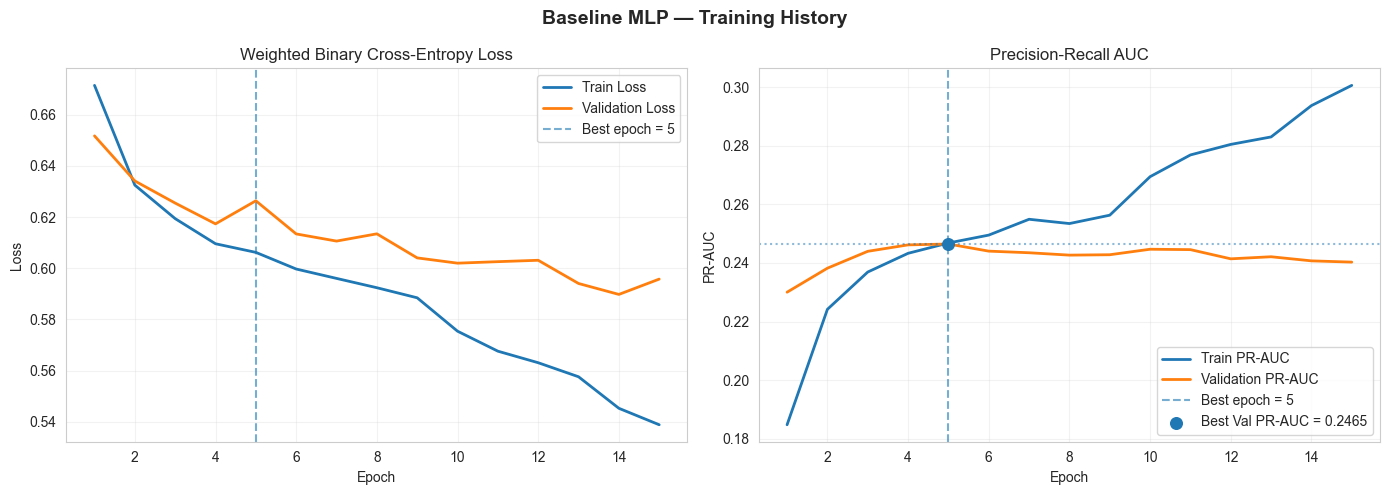

Best epoch: 5 | Best validation PR-AUC: 0.2465


In [44]:
def plot_history(history, title, filename):
    hist = history.history

    epochs = np.arange(1, len(hist["loss"]) + 1)

    best_epoch_idx = int(np.argmax(hist["val_pr_auc"]))
    best_epoch = best_epoch_idx + 1
    best_val_pr_auc = hist["val_pr_auc"][best_epoch_idx]

    fig, axes = plt.subplots(
        1, 2,
        figsize=(14, 5)
    )

    # Loss
    axes[0].plot(
        epochs,
        hist["loss"],
        label="Train Loss",
        linewidth=2
    )

    axes[0].plot(
        epochs,
        hist["val_loss"],
        label="Validation Loss",
        linewidth=2
    )

    axes[0].axvline(
        best_epoch,
        linestyle="--",
        alpha=0.6,
        label=f"Best epoch = {best_epoch}"
    )

    axes[0].set_title("Weighted Binary Cross-Entropy Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")

    axes[0].legend()
    axes[0].grid(alpha=0.25)

    # PR-AUC
    axes[1].plot(
        epochs,
        hist["pr_auc"],
        label="Train PR-AUC",
        linewidth=2
    )

    axes[1].plot(
        epochs,
        hist["val_pr_auc"],
        label="Validation PR-AUC",
        linewidth=2
    )

    axes[1].axvline(
        best_epoch,
        linestyle="--",
        alpha=0.6,
        label=f"Best epoch = {best_epoch}"
    )

    axes[1].scatter(
        best_epoch,
        best_val_pr_auc,
        s=70,
        zorder=5,
        label=f"Best Val PR-AUC = {best_val_pr_auc:.4f}"
    )

    axes[1].axhline(
        best_val_pr_auc,
        linestyle=":",
        alpha=0.5
    )

    axes[1].set_title("Precision-Recall AUC")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("PR-AUC")
    axes[1].legend()
    axes[1].grid(alpha=0.25)

    fig.suptitle(
        title,
        fontsize=14,
        fontweight="bold"
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(FIGURES_DIR, filename),
        dpi=160,
        bbox_inches="tight"
    )

    plt.show()

    print(
        f"Best epoch: {best_epoch} | "
        f"Best validation PR-AUC: {best_val_pr_auc:.4f}"
    )


plot_history(
    history_baseline,
    "Baseline MLP — Training History",
    "dl_baseline_training_history.png"
)

## 6. Evaluate the baseline on VAL

One reusable metrics function, used identically for every model and every split from here on — the
MLP configurations, the final Test evaluation and the classical champion all go through it, so no
comparison is ever distorted by a difference in how the numbers were computed.

In [45]:
def evaluate_probabilities(y_true, y_proba, threshold=0.5, label=""):
    "All reported metrics for one set of predicted probabilities."
    y_true = np.asarray(y_true).astype(int)
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "label": label,
        "threshold": float(threshold),
        "pr_auc": average_precision_score(y_true, y_proba),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "brier_score": brier_score_loss(y_true, y_proba),
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
        "business_cost": int(fn * FN_COST + fp * FP_COST),
    }


val_proba_baseline = mlp_baseline.predict(X_val_t, batch_size=4096, verbose=0).ravel()
baseline_val_metrics = evaluate_probabilities(y_val_a, val_proba_baseline, 0.5, "MLP baseline (VAL)")

print(pd.Series(baseline_val_metrics).to_string())
print("\nNote: metrics at the default 0.5 cut-off are diagnostic only.")
print("The decision threshold is chosen on business cost in Section 10.")

label            MLP baseline (VAL)
threshold                       0.5
pr_auc                      0.24679
roc_auc                      0.7654
recall                     0.718698
precision                  0.165379
f1                         0.268885
brier_score                0.202875
TN                            23117
FP                            10805
FN                              838
TP                             2141
business_cost                 19185

Note: metrics at the default 0.5 cut-off are diagnostic only.
The decision threshold is chosen on business cost in Section 10.


## 7. One additional configuration

Per the plan: a single alternative, not a hyperparameter sweep. The baseline is regularized fairly
heavily, so the informative question is what a **wider first layer with stronger dropout** does —
more capacity to model feature interactions, more pressure against memorizing them.

If this configuration does not beat the baseline on validation PR-AUC, the baseline is kept. That is
a legitimate result and gets reported as such, rather than being tuned away.

Epoch 1/100
337/337 - 3s - 10ms/step - loss: 0.7079 - pr_auc: 0.1777 - roc_auc: 0.7109 - val_loss: 0.6863 - val_pr_auc: 0.2320 - val_roc_auc: 0.7533 - learning_rate: 0.0010
Epoch 2/100
337/337 - 2s - 7ms/step - loss: 0.6593 - pr_auc: 0.2240 - roc_auc: 0.7519 - val_loss: 0.6713 - val_pr_auc: 0.2426 - val_roc_auc: 0.7625 - learning_rate: 0.0010
Epoch 3/100
337/337 - 2s - 7ms/step - loss: 0.6432 - pr_auc: 0.2350 - roc_auc: 0.7619 - val_loss: 0.6661 - val_pr_auc: 0.2456 - val_roc_auc: 0.7659 - learning_rate: 0.0010
Epoch 4/100
337/337 - 2s - 7ms/step - loss: 0.6330 - pr_auc: 0.2385 - roc_auc: 0.7663 - val_loss: 0.6397 - val_pr_auc: 0.2422 - val_roc_auc: 0.7645 - learning_rate: 0.0010
Epoch 5/100
337/337 - 2s - 7ms/step - loss: 0.6233 - pr_auc: 0.2447 - roc_auc: 0.7704 - val_loss: 0.6384 - val_pr_auc: 0.2429 - val_roc_auc: 0.7655 - learning_rate: 0.0010
Epoch 6/100
337/337 - 2s - 7ms/step - loss: 0.6176 - pr_auc: 0.2426 - roc_auc: 0.7722 - val_loss: 0.6400 - val_pr_auc: 0.2428 - val_roc_auc

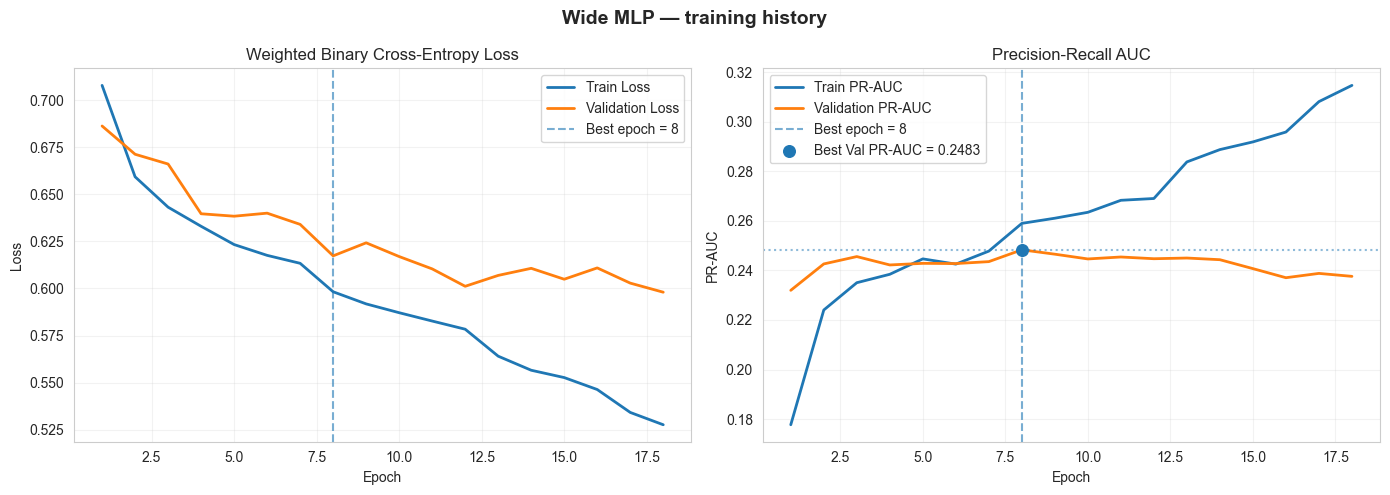

Best epoch: 8 | Best validation PR-AUC: 0.2483

Best validation PR-AUC: 0.2483


In [46]:
keras.utils.set_random_seed(42)

mlp_wide = build_mlp(
    INPUT_DIM,
    hidden_units=(512, 128),
    dropout_rates=(0.4, 0.3),
    l2_reg=1e-4,
    learning_rate=1e-3,
    name="mlp_wide",
)

history_wide = mlp_wide.fit(
    X_sub_t, y_sub_a,
    validation_data=(X_val_t, y_val_a),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=make_callbacks(),
    verbose=2,
)

plot_history(history_wide, "Wide MLP — training history", "dl_wide_training_history.png")

val_proba_wide = mlp_wide.predict(X_val_t, batch_size=4096, verbose=0).ravel()
wide_val_metrics = evaluate_probabilities(y_val_a, val_proba_wide, 0.5, "MLP wide (VAL)")
print("\nBest validation PR-AUC:", round(max(history_wide.history["val_pr_auc"]), 4))

## 8. Select the best MLP — by validation PR-AUC

In [48]:
# MLP Configuration Comparison

baseline_best_pr_auc = max(
    history_baseline.history["val_pr_auc"]
)

wide_best_pr_auc = max(
    history_wide.history["val_pr_auc"]
)

baseline_best_epoch = (
    np.argmax(history_baseline.history["val_pr_auc"]) + 1
)

wide_best_epoch = (
    np.argmax(history_wide.history["val_pr_auc"]) + 1
)

comparison_df = pd.DataFrame({
    "Model": [
        "Baseline MLP",
        "Wide MLP"
    ],
    "Architecture": [
        "716 → 256 → 64 → 1",
        "716 → 512 → 128 → 1"
    ],
    "Dropout": [
        "0.3 → 0.2",
        "0.4 → 0.3"
    ],
    "L2": [
        1e-4,
        1e-4
    ],
    "Best Val PR-AUC": [
        baseline_best_pr_auc,
        wide_best_pr_auc
    ],
    "Best Epoch": [
        baseline_best_epoch,
        wide_best_epoch
    ]
})

# Format only for display
display_df = comparison_df.copy()
display_df["L2"] = display_df["L2"].map(
    lambda x: f"{x:.0e}"
)
display_df["Best Val PR-AUC"] = display_df[
    "Best Val PR-AUC"
].map(
    lambda x: f"{x:.4f}"
)

print("MLP CONFIGURATION COMPARISON")
display(display_df)


# Select the best configuration

if wide_best_pr_auc > baseline_best_pr_auc:
    selected_mlp = mlp_wide
    selected_history = history_wide
    selected_mlp_name = "Wide MLP"
else:
    selected_mlp = mlp_baseline
    selected_history = history_baseline
    selected_mlp_name = "Baseline MLP"

print(f"\nSelected model: {selected_mlp_name}")
print(
    f"Best validation PR-AUC: "
    f"{max(selected_history.history['val_pr_auc']):.4f}"
)

MLP CONFIGURATION COMPARISON


,Model,Architecture,Dropout,L2,Best Val PR-AUC,Best Epoch
0,Baseline MLP,716 → 256 → 64 → 1,0.3 → 0.2,1e-04,0.2465,5
1,Wide MLP,716 → 512 → 128 → 1,0.4 → 0.3,1e-04,0.2483,8



Selected model: Wide MLP
Best validation PR-AUC: 0.2483


## 9. Probability calibration — on the CAL split

A network trained with `class_weight` produces **systematically inflated** probabilities: the loss was
told a default costs ~6.2× a non-default, so the output stops being an estimate of P(default) and
becomes a weighted score. For a risk platform that reports a probability to a credit officer, that has
to be corrected, and the Brier score is what measures whether it was.

Sigmoid (Platt) and isotonic are both fitted on `CAL` — a split the network never trained on and which
played no part in selecting the configuration. Lowest Brier wins, matching the classical track's rule.

In [50]:
cal_proba_raw = best_mlp.predict(X_cal_t, batch_size=4096, verbose=0).ravel()

uncalibrated_brier = brier_score_loss(y_cal_a, cal_proba_raw)

# Sigmoid / Platt scaling
sigmoid_calibrator = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
sigmoid_calibrator.fit(cal_proba_raw.reshape(-1, 1), y_cal_a)
cal_proba_sigmoid = sigmoid_calibrator.predict_proba(cal_proba_raw.reshape(-1, 1))[:, 1]
sigmoid_brier = brier_score_loss(y_cal_a, cal_proba_sigmoid)

# Isotonic regression
isotonic_calibrator = IsotonicRegression(out_of_bounds="clip")
isotonic_calibrator.fit(cal_proba_raw, y_cal_a)
cal_proba_isotonic = isotonic_calibrator.predict(cal_proba_raw)
isotonic_brier = brier_score_loss(y_cal_a, cal_proba_isotonic)

calibration_comparison = pd.DataFrame([
    {"method": "none",     "brier_score": uncalibrated_brier},
    {"method": "sigmoid",  "brier_score": sigmoid_brier},
    {"method": "isotonic", "brier_score": isotonic_brier},
]).sort_values("brier_score").reset_index(drop=True)

print(calibration_comparison.round(5).to_string(index=False))
calibration_comparison.to_csv(os.path.join(REPORTS_DIR, "dl_calibration_comparison.csv"), index=False)

selected_method = calibration_comparison.iloc[0]["method"]
calibrators = {"none": None, "sigmoid": sigmoid_calibrator, "isotonic": isotonic_calibrator}
selected_calibrator = calibrators[selected_method]

print(f"\nSelected calibration method: {selected_method} "
      f"(Brier {calibration_comparison.iloc[0]['brier_score']:.5f}, "
      f"uncalibrated {uncalibrated_brier:.5f})")

  method  brier_score
isotonic      0.06758
 sigmoid      0.06783
    none      0.19801

Selected calibration method: isotonic (Brier 0.06758, uncalibrated 0.19801)


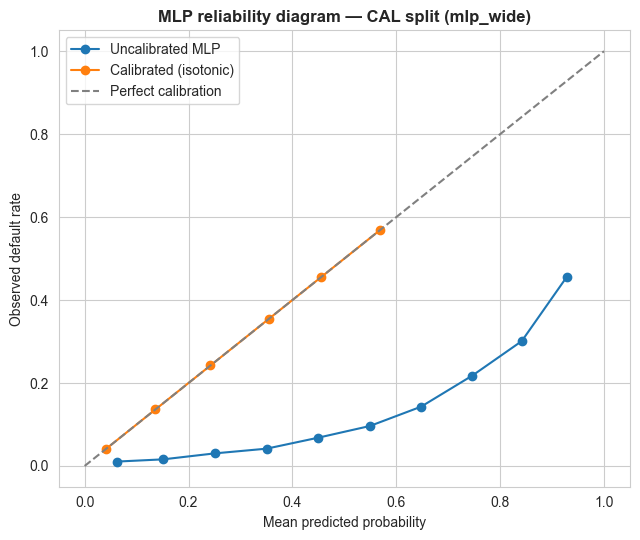

In [51]:
def apply_calibration(raw_proba, method, calibrator):
    "Single entry point for calibration - used for CAL, Test and nowhere else."
    if method == "none":
        return raw_proba
    if method == "isotonic":
        return calibrator.predict(raw_proba)
    if method == "sigmoid":
        return calibrator.predict_proba(raw_proba.reshape(-1, 1))[:, 1]
    raise ValueError(f"Unknown calibration method: {method}")


cal_proba_calibrated = apply_calibration(cal_proba_raw, selected_method, selected_calibrator)

# Reliability diagram - before vs after
frac_raw, mean_raw = calibration_curve(y_cal_a, cal_proba_raw, n_bins=10)
frac_cal, mean_cal = calibration_curve(y_cal_a, cal_proba_calibrated, n_bins=10)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.plot(mean_raw, frac_raw, marker="o", label="Uncalibrated MLP")
ax.plot(mean_cal, frac_cal, marker="o", label=f"Calibrated ({selected_method})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed default rate")
ax.set_title(f"MLP reliability diagram — CAL split ({best_mlp_name})", fontsize=12, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "dl_calibration_reliability.png"), dpi=150, bbox_inches="tight")
plt.show()

## 10. Threshold optimization — business cost, on CAL only

`FN_COST = 10`, `FP_COST = 1`: missing a default is assumed to cost ten times as much as rejecting a
good applicant. These are illustrative values carried over unchanged from the classical track — what
drives the decision is the **ratio**, and a real institution would substitute its own unit economics.

The threshold is swept over the *calibrated* probabilities on `CAL`, never on Test.

In [52]:
thresholds = np.linspace(0.01, 0.99, 99)

threshold_rows = []
for t in thresholds:
    pred = (cal_proba_calibrated >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_cal_a.astype(int), pred).ravel()
    threshold_rows.append({
        "threshold": t, "TN": tn, "FP": fp, "FN": fn, "TP": tp,
        "recall": recall_score(y_cal_a, pred, zero_division=0),
        "precision": precision_score(y_cal_a, pred, zero_division=0),
        "f1": f1_score(y_cal_a, pred, zero_division=0),
        "business_cost": fn * FN_COST + fp * FP_COST,
    })

threshold_df = pd.DataFrame(threshold_rows)
threshold_df.to_csv(os.path.join(REPORTS_DIR, "dl_threshold_analysis.csv"), index=False)

best_row = threshold_df.loc[threshold_df["business_cost"].idxmin()]
mlp_threshold = float(best_row["threshold"])

print(f"Optimal threshold: {mlp_threshold:.3f}")
print(f"Minimum CAL business cost: {int(best_row['business_cost']):,}")
print(f"Cost at the naive 0.50 cut-off: "
      f"{int(threshold_df.loc[(threshold_df['threshold'] - 0.5).abs().idxmin(), 'business_cost']):,}")
print(f"\nAt the optimal threshold - recall {best_row['recall']:.4f}, "
      f"precision {best_row['precision']:.4f}, FN {int(best_row['FN'])}, FP {int(best_row['FP'])}")

Optimal threshold: 0.090
Minimum CAL business cost: 19,164
Cost at the naive 0.50 cut-off: 29,504

At the optimal threshold - recall 0.6542, precision 0.1802, FN 1030, FP 8864


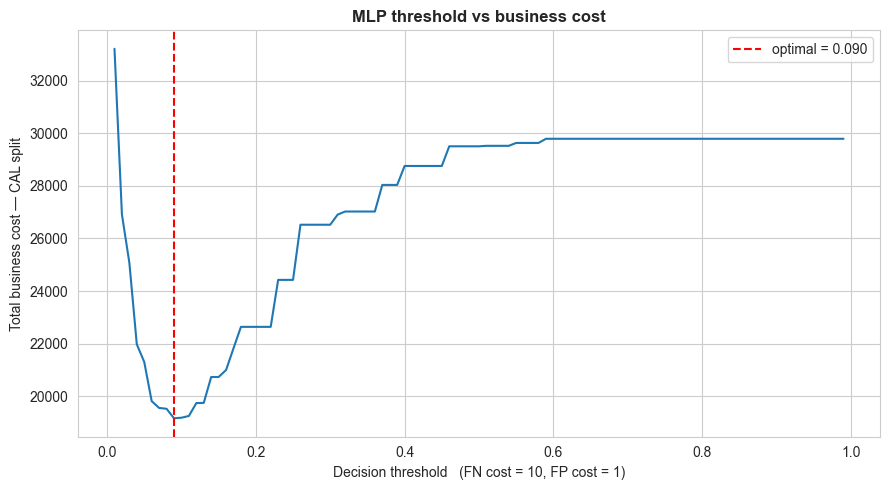

In [53]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(threshold_df["threshold"], threshold_df["business_cost"])
ax.axvline(mlp_threshold, linestyle="--", color="red",
           label=f"optimal = {mlp_threshold:.3f}")
ax.set_xlabel(f"Decision threshold   (FN cost = {FN_COST}, FP cost = {FP_COST})")
ax.set_ylabel("Total business cost — CAL split")
ax.set_title("MLP threshold vs business cost", fontsize=12, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "dl_threshold_cost_curve.png"), dpi=150, bbox_inches="tight")
plt.show()

## 11. Freeze the final DL pipeline

The four pieces that together define one prediction, fixed here and used unchanged in Section 12:

1. `mlp_preprocessor` — fitted on SUB-TRAIN
2. `best_mlp` — the selected architecture with its restored best weights
3. `selected_calibrator` / `selected_method` — fitted on CAL
4. `mlp_threshold` — optimized on CAL

Nothing below this point is refitted. As explained in the header, there is deliberately **no retrain
on the full Train set**: it would change the probability distribution that pieces 3 and 4 were fitted
to, and neither could be trusted afterwards.

In [54]:
def predict_risk(X_raw, return_label=True):
    "Raw applicant rows -> calibrated default probability (and optional decision)."
    X_t = mlp_preprocessor.transform(X_raw).astype("float32")
    raw = best_mlp.predict(X_t, batch_size=4096, verbose=0).ravel()
    proba = apply_calibration(raw, selected_method, selected_calibrator)
    if return_label:
        return proba, (proba >= mlp_threshold).astype(int)
    return proba


dl_pipeline_config = {
    "architecture": best_mlp_name,
    "input_dim": int(INPUT_DIM),
    "n_parameters": int(best_mlp.count_params()),
    "calibration_method": selected_method,
    "decision_threshold": mlp_threshold,
    "class_weight": class_weight_dict,
    "fn_cost": FN_COST,
    "fp_cost": FP_COST,
    "trained_on": "SUB-TRAIN (70% of Train); no retrain after calibration - see Section 11",
}

print(json.dumps(dl_pipeline_config, indent=2))

{
  "architecture": "mlp_wide",
  "input_dim": 716,
  "n_parameters": 432897,
  "calibration_method": "isotonic",
  "decision_threshold": 0.09,
  "class_weight": {
    "0": 0.5439094647606173,
    "1": 6.193533304560495
  },
  "fn_cost": 10,
  "fp_cost": 1,
  "trained_on": "SUB-TRAIN (70% of Train); no retrain after calibration - see Section 11"
}


## 12. Final Test evaluation — the only time Test is used

`X_test` is transformed, scored, calibrated and thresholded in a single pass, with every component
frozen above. This cell is run **once**. If its result is disappointing, the honest move is to report
it, not to go back and re-tune against it — doing that turns Test into a validation set and the
reported number stops meaning anything.

In [56]:
test_proba_mlp, test_pred_mlp = predict_risk(X_test)

mlp_test_metrics = evaluate_probabilities(y_test, test_proba_mlp, mlp_threshold, "MLP (Test)")

print("FINAL MLP TEST RESULTS :")
for k in ["pr_auc", "roc_auc", "recall", "precision", "f1", "brier_score"]:
    print(f"  {k:<14}: {mlp_test_metrics[k]:.4f}")
print(f"  {'business_cost':<14}: {mlp_test_metrics['business_cost']:,}")

print("\nConfusion matrix (Test):")
print(pd.DataFrame(
    [[mlp_test_metrics["TN"], mlp_test_metrics["FP"]],
     [mlp_test_metrics["FN"], mlp_test_metrics["TP"]]],
    index=["Actual 0", "Actual 1"], columns=["Pred 0", "Pred 1"],
))

print(f"\nTest default rate: {y_test.mean():.4%} | Train default rate: {y_train.mean():.4%}")

FINAL MLP TEST RESULTS :
  pr_auc        : 0.2475
  roc_auc       : 0.7691
  recall        : 0.6645
  precision     : 0.1858
  f1            : 0.2904
  brier_score   : 0.0671
  business_cost : 31,118

Confusion matrix (Test):
          Pred 0  Pred 1
Actual 0   42080   14458
Actual 1    1666    3299

Test default rate: 8.0728% | Train default rate: 8.0729%


## 13. MLP vs the Classical Champion

The finalized MLP and the saved Logistic Regression Champion were evaluated on the same Test set using the same metrics and business cost matrix.

Logistic Regression achieved the best PR-AUC and remains the final Classical Champion.

The MLP achieved a slightly better F1 score and lower business cost, but did not provide a meaningful overall improvement over Logistic Regression.

The MLP is therefore retained as the Deep Learning comparison model.

In [57]:
# Score the classical champion on Test, using its own saved calibration + threshold
champion_raw_test = champion_pipeline.predict_proba(X_test)[:, 1]

if champion_calibrator is not None and champion_calib_method:
    if champion_calib_method == "isotonic":
        champion_test_proba = champion_calibrator.predict(champion_raw_test)
    else:
        champion_test_proba = champion_calibrator.predict_proba(champion_raw_test.reshape(-1, 1))[:, 1]
else:
    champion_test_proba = champion_raw_test
    print("[warn] No calibrator found in the champion bundle - using raw probabilities.")

champion_thr = champion_threshold if champion_threshold is not None else 0.5
champion_test_metrics = evaluate_probabilities(
    y_test, champion_test_proba, champion_thr, f"{champion_name} (Test)"
)

comparison_df = pd.DataFrame([champion_test_metrics, mlp_test_metrics])[[
    "label", "threshold", "pr_auc", "roc_auc", "recall", "precision",
    "f1", "brier_score", "TN", "FP", "FN", "TP", "business_cost",
]]

print(comparison_df.round(4).to_string(index=False))
comparison_df.to_csv(os.path.join(REPORTS_DIR, "dl_vs_classical_comparison.csv"), index=False)

delta_pr = mlp_test_metrics["pr_auc"] - champion_test_metrics["pr_auc"]
delta_cost = mlp_test_metrics["business_cost"] - champion_test_metrics["business_cost"]
print(f"\nMLP - {champion_name}:  PR-AUC {delta_pr:+.4f} | business cost {delta_cost:+,}")
print("(negative business cost = the MLP is cheaper under the assumed cost matrix)")

                    label  threshold  pr_auc  roc_auc  recall  precision     f1  brier_score    TN    FP   FN   TP  business_cost
LogisticRegression (Test)       0.09  0.2569   0.7747  0.6731     0.1816 0.2860       0.0668 41475 15063 1623 3342          31293
               MLP (Test)       0.09  0.2475   0.7691  0.6645     0.1858 0.2904       0.0671 42080 14458 1666 3299          31118

MLP - LogisticRegression:  PR-AUC -0.0094 | business cost -175
(negative business cost = the MLP is cheaper under the assumed cost matrix)


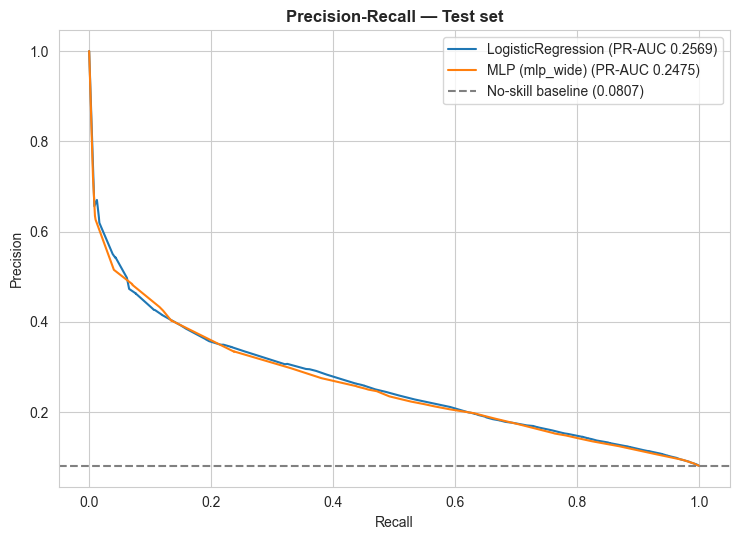

In [58]:
# Side-by-side PR curves on Test
from sklearn.metrics import precision_recall_curve

fig, ax = plt.subplots(figsize=(7.5, 5.5))
for proba, name in [(champion_test_proba, champion_name), (test_proba_mlp, f"MLP ({best_mlp_name})")]:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ax.plot(rec, prec, label=f"{name} (PR-AUC {average_precision_score(y_test, proba):.4f})")

ax.axhline(y_test.mean(), linestyle="--", color="gray",
           label=f"No-skill baseline ({y_test.mean():.4f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision-Recall — Test set", fontsize=12, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "dl_vs_classical_pr_curve.png"), dpi=150, bbox_inches="tight")
plt.show()

In [59]:
# Risk-segment error analysis for the MLP - same five-bucket layout as the classical track
segment_df = pd.DataFrame({
    "y_true": np.asarray(y_test).astype(int),
    "y_proba": test_proba_mlp,
    "y_pred": test_pred_mlp,
})
# Rank first, then cut: a calibrated (especially isotonic) MLP produces many tied
# probabilities, and qcut on tied values collapses bins and breaks the labels.
segment_df["risk_segment"] = pd.qcut(
    segment_df["y_proba"].rank(method="first"), q=5,
    labels=["1 (lowest risk)", "2", "3", "4", "5 (highest risk)"],
)

segment_summary = segment_df.groupby("risk_segment", observed=True).apply(
    lambda g: pd.Series({
        "n_applicants": len(g),
        "actual_default_rate": g["y_true"].mean(),
        "mean_predicted_probability": g["y_proba"].mean(),
        "false_negatives": int(((g["y_true"] == 1) & (g["y_pred"] == 0)).sum()),
        "false_positives": int(((g["y_true"] == 0) & (g["y_pred"] == 1)).sum()),
    })
)

print("Risk-segment analysis — MLP (Test)")
print(segment_summary.round(4).to_string())
segment_summary.to_csv(os.path.join(REPORTS_DIR, "dl_risk_segment_error_analysis.csv"))
print("\nA monotonically rising actual default rate across segments means the ranking is sound,")
print("independently of where the decision threshold happens to sit.")

Risk-segment analysis — MLP (Test)
                  n_applicants  actual_default_rate  mean_predicted_probability  false_negatives  false_positives
risk_segment                                                                                                     
1 (lowest risk)        12301.0               0.0153                      0.0133            188.0              0.0
2                      12300.0               0.0312                      0.0314            384.0              0.0
3                      12301.0               0.0501                      0.0500            616.0              0.0
4                      12300.0               0.0881                      0.0943            478.0           4850.0
5 (highest risk)       12301.0               0.2189                      0.2120              0.0           9608.0

A monotonically rising actual default rate across segments means the ranking is sound,
independently of where the decision threshold happens to sit.


C:\Users\Kirolos George\AppData\Local\Temp\ipykernel_20972\1522110372.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  segment_summary = segment_df.groupby("risk_segment", observed=True).apply(


## 14. Save the DL artifacts

Everything the Streamlit app and the final report need. The preprocessor is saved **alongside** the
model because it was fitted on SUB-TRAIN and is therefore not interchangeable with
`preprocessing_pipeline.joblib`.

In [60]:
DL_MODEL_PATH      = os.path.join(MODELS_DIR, "best_mlp_model.keras")
DL_PREPROC_PATH    = os.path.join(MODELS_DIR, "mlp_preprocessing_pipeline.joblib")
DL_CALIBRATOR_PATH = os.path.join(MODELS_DIR, "mlp_calibrator.joblib")
DL_METADATA_PATH   = os.path.join(REPORTS_DIR, "dl_model_metadata.json")

best_mlp.save(DL_MODEL_PATH)
joblib.dump(mlp_preprocessor, DL_PREPROC_PATH)
joblib.dump({"method": selected_method, "calibrator": selected_calibrator}, DL_CALIBRATOR_PATH)

dl_metadata = {
    "model_name": "MLP",
    "architecture": best_mlp_name,
    "framework": f"tensorflow-keras {tf.__version__}",
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "random_state": RANDOM_STATE,

    "input_dim": int(INPUT_DIM),
    "n_parameters": int(best_mlp.count_params()),
    "n_features_raw": int(X_train.shape[1]),

    "split_design": {
        "sub_train_rows": int(len(X_sub)),
        "val_rows": int(len(X_val)),
        "cal_rows": int(len(X_cal)),
        "test_rows": int(len(X_test)),
        "final_training_data": "SUB-TRAIN",
        "validation_purpose": "Early stopping and MLP configuration selection",
        "calibration_threshold_data": "CAL",
        "test_usage": "Final evaluation only",
    },

    "imbalance_strategy": "class_weight",
    "class_weight": class_weight_dict,

    "calibration_method": selected_method,
    "decision_threshold": float(mlp_threshold),

    "cost_matrix": {
        "FN_COST": FN_COST,
        "FP_COST": FP_COST,
    },

    "final_model_policy": {
        "trained_on": "SUB-TRAIN",
        "retrained_after_calibration": False,
        "reason": (
            "The selected MLP weights are frozen before calibration and threshold "
            "selection to keep the calibration and decision pipeline consistent."
        ),
    },

    "test_metrics": {
        k: float(v)
        for k, v in mlp_test_metrics.items()
        if k != "label"
        and isinstance(v, (int, float, np.floating))
    },

    "classical_champion": {
        "model": champion_name,
        "test_metrics": {
            k: float(v)
            for k, v in champion_test_metrics.items()
            if k != "label"
            and isinstance(v, (int, float, np.floating))
        },
    },

    "artifacts": {
        "model": "models/versioned_artifacts/best_mlp_model.keras",
        "preprocessor": "models/versioned_artifacts/mlp_preprocessing_pipeline.joblib",
        "calibrator": "models/versioned_artifacts/mlp_calibrator.joblib",
    },
}

with open(DL_METADATA_PATH, "w") as f:
    json.dump(dl_metadata, f, indent=2)

print("[saved]", DL_MODEL_PATH)
print("[saved]", DL_PREPROC_PATH)
print("[saved]", DL_CALIBRATOR_PATH)
print("[saved]", DL_METADATA_PATH)
print("[saved]", os.path.join(REPORTS_DIR, "dl_vs_classical_comparison.csv"))

[saved] C:\Users\Kirolos George\OneDrive - Alexandria University\Desktop\projects\tech_trek_internship\credit risk project structure Project\project-name\models\versioned_artifacts\best_mlp_model.keras
[saved] C:\Users\Kirolos George\OneDrive - Alexandria University\Desktop\projects\tech_trek_internship\credit risk project structure Project\project-name\models\versioned_artifacts\mlp_preprocessing_pipeline.joblib
[saved] C:\Users\Kirolos George\OneDrive - Alexandria University\Desktop\projects\tech_trek_internship\credit risk project structure Project\project-name\models\versioned_artifacts\mlp_calibrator.joblib
[saved] C:\Users\Kirolos George\OneDrive - Alexandria University\Desktop\projects\tech_trek_internship\credit risk project structure Project\project-name\reports\dl_model_metadata.json
[saved] C:\Users\Kirolos George\OneDrive - Alexandria University\Desktop\projects\tech_trek_internship\credit risk project structure Project\project-name\reports\dl_vs_classical_comparison.csv


In [61]:
# Reload Consistency Check

# Reload saved artifacts
reloaded_model = keras.models.load_model(DL_MODEL_PATH)
reloaded_preproc = joblib.load(DL_PREPROC_PATH)
reloaded_cal = joblib.load(DL_CALIBRATOR_PATH)

# Use the same Test samples that were already evaluated
sample = X_test.head(500)

# Reproduce the complete prediction pipeline
sample_t = reloaded_preproc.transform(sample).astype("float32")

raw_reloaded = reloaded_model.predict(
    sample_t,
    batch_size=512,
    verbose=0
).ravel()

reloaded_proba = apply_calibration(
    raw_reloaded,
    reloaded_cal["method"],
    reloaded_cal["calibrator"]
)

# Compare with the original notebook predictions
original_proba = test_proba_mlp[:500]

max_diff = np.max(
    np.abs(reloaded_proba - original_proba)
)

print(f"Max probability difference after reload: {max_diff:.3e}")

assert max_diff < 1e-5, (
    "Reloaded artifacts do not reproduce the original "
    "in-notebook predictions!"
)

print("\n[OK] Reloaded artifacts reproduce the notebook predictions.")
print("[OK] Model, preprocessing, and calibration pipeline are consistent.")

Max probability difference after reload: 0.000e+00

[OK] Reloaded artifacts reproduce the notebook predictions.
[OK] Model, preprocessing, and calibration pipeline are consistent.


## 15. Deep Learning track — summary

Fill the numbers in from the cells above when writing the final report; the structure of the argument
is what matters for the defense:

- **What was built**: an MLP on the same 716 preprocessed features, trained on 70% of Train with
  `class_weight`, early-stopped on validation PR-AUC, calibrated and thresholded on a held-out split.
- **What was compared**: MLP vs the calibrated Logistic Regression champion on the same Test set,
  the same metrics and the same cost matrix.
- **What to claim**: the ranking quality (PR-AUC, ROC-AUC), the calibration quality (Brier), and the
  cost under the stated FN:FP ratio — in that order.
- **What not to claim**: that this is a lending approval system. It is decision support, and the
  threshold rests on an assumed cost ratio that a real institution would replace.

**Next**: `05_explainability.ipynb` — SHAP on the classical champion, plus the fairness and drift
sections from the distinction list.

## Current Project Structure

```text
project-name/
│
├── data/
│   ├── raw/
│   │   └── Home Credit raw CSV files
│   │
│   └── processed/
│       ├── final_feature_dataset.csv
│       ├── X_train.csv
│       ├── X_test.csv
│       ├── y_train.csv
│       └── y_test.csv
│
├── notebooks/
│   ├── 01_eda.ipynb
│   ├── 02_feature_engineering.ipynb
│   ├── 03_ml_experiments.ipynb
│   └── 04_dl_experiments.ipynb
│
├── src/
│   └── data/
│       └── collected_dataset.csv
│
│
├── app/
│
├── models/
│   └── versioned_artifacts/
│       ├── preprocessing_pipeline.joblib
│       ├── logistic_regression_final.joblib
│       ├── xgboost_final.joblib
│       ├── best_classical_model.joblib
│       ├── best_mlp_model.keras
│       ├── mlp_preprocessing_pipeline.joblib
│       └── mlp_calibrator.joblib
│
├── reports/
│   ├── figures/
│   │   ├── EDA figures
│   │   ├── ML figures
│   │   ├── dl_baseline_training_history.png
│   │   └── dl_wide_training_history.png
│   │
│   ├── eda_decision_log.csv
│   ├── final_ml_feature_list.json
│   ├── validation_strategy.json
│   ├── model_comparison_cv_results.csv
│   ├── tuned_model_comparison.csv
│   ├── threshold_analysis.csv
│   ├── optimal_thresholds.json
│   ├── calibration_comparison.csv
│   ├── selected_calibration_methods.json
│   ├── final_thresholds_after_calibration.json
│   ├── final_test_model_comparison.csv
│   ├── feature_importance_*.csv
│   ├── risk_segment_error_analysis_*.csv
│   ├── final_model_metadata.json
│   ├── dl_calibration_comparison.csv
│   ├── dl_threshold_analysis.csv
│   ├── dl_model_metadata.json
│   ├── dl_vs_classical_comparison.csv
│   └── mlp_configuration_comparison.csv
│
└── requirements.txt

